<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [214]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

In [215]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [216]:
import torch.nn as nn
import torchaudio
import torch
from torch.utils.data import Dataset
#import torch_audiomentations
import pandas as pd
import os
import random

label_map = {v: i for i, v in enumerate(train_df.category.value_counts().index.values)}

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, dataframe, sample_rate=16000, max_len = 80000, test=False, do_augmentation=False,):

        self.dataframe = dataframe
        self.sample_rate = sample_rate
        self.do_augmentation = do_augmentation
        self.max_len = max_len
        self.test = test
        self.classes = train_df.category.value_counts().index.values
        self.target_length_samples = max_len 

            
    def __len__(self):
        return len(self.dataframe) 

    def __getitem__(self, index):
        # 1. Get the file path and label
        audio_file_path = self.dataframe.iloc[index].filename # here is your code
        label = label_map[self.dataframe.iloc[index].category] if not self.test else None
        
        # 2. LOAD: Load the raw audio file
        wav, sr = torchaudio.load(f'D:\Projects\DeepLearningSound\sound_classification_dataset\{audio_file_path}')
        

        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(wav, sr, self.sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = signal[None, :, :]
            signal = self._augmentation(signal)
            signal = signal[:, 0, :]
        
        signal = signal.squeeze(1)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        if not self.test:
          return signal, label
        else:
          return signal

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr, new_sr):
        # here is your code
        resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=new_sr)
        signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        # here is your code
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        # here is your code
        current_length = signal.shape[1]
        target_length = self.target_length_samples
        if current_length < target_length:
            padding = target_length - current_length
            signal = torch.nn.functional.pad(signal, (0, padding))

        elif current_length > target_length:
            start = (current_length - target_length) // 2
            signal = signal[:, start:start + target_length]
        return signal

    def _augmentation(self, signal):
        # Добавление шума
        if random.random() > 0.5:
            noise = torch.randn_like(signal) * 0.005
            signal = signal + noise
        
        # Изменение громкости
        if random.random() > 0.5:
            gain = random.uniform(0.7, 1.3)
            signal = signal * gain
        
        # Сдвиг по времени (циклический сдвиг)
        if random.random() > 0.5 and signal.shape[1] > 1000:
            shift_amount = random.randint(0, signal.shape[1] // 4)
            signal = torch.roll(signal, shifts=shift_amount, dims=1)
        
        return signal


In [217]:
train_dataset = SimpleAudioDataset(train_df, do_augmentation=True)
valid_dataset = SimpleAudioDataset(valid_df)

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [218]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [219]:
class SoundClassificationModel(nn.Module):
    """A simple model that processes raw waveforms."""

    def __init__(self, input_dim=80000, input_size=16000, num_classes=5, p=0.5):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 64, kernel_size=15, stride=1, padding=7)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(8)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=11, stride=1, padding=5)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(8)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=9, stride=1, padding=4)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(5)

        self.fc = nn.Linear(256, 5)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.nonlin = nn.ReLU()
        self.dropout = nn.Dropout(p)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.nonlin(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = self.nonlin(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = self.nonlin(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        x = self.softmax(self.fc(x))
        return x



### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [220]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


In [221]:
def calculate_accuracy(predictions, labels):
    _, predicted = torch.max(predictions, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total


Using device: cuda
Epoch 1/15:
Train Loss: 1.5035, Train Acc: 0.4583
Valid Loss: 1.6112, Valid Acc: 0.2750
--------------------------------------------------


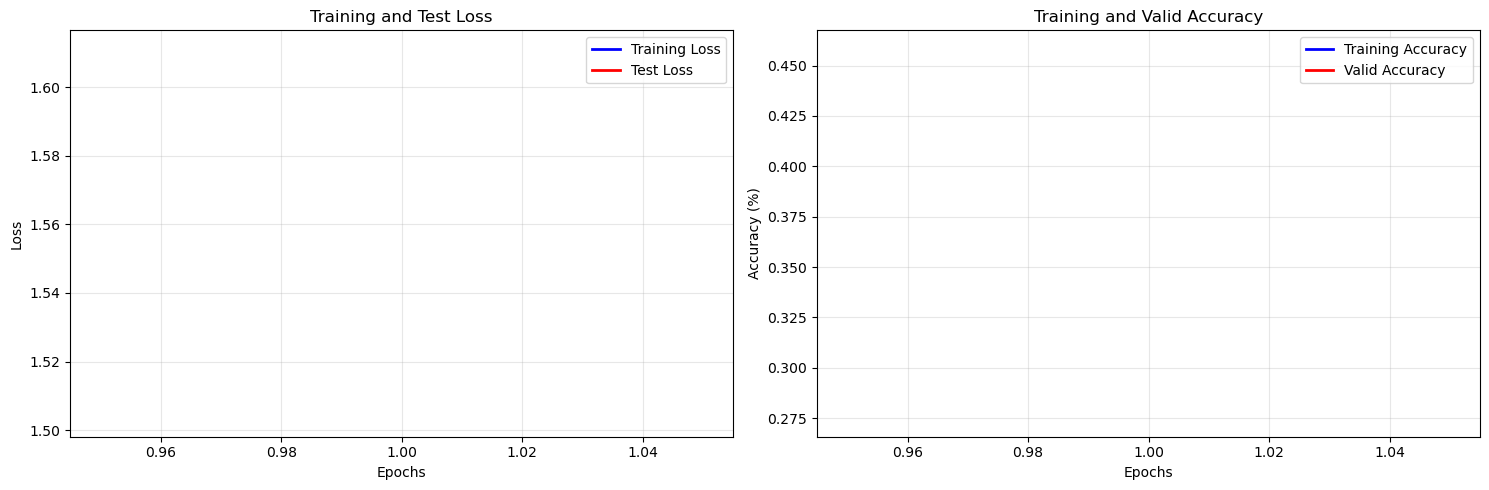

Epoch 2/15:
Train Loss: 1.4016, Train Acc: 0.6083
Valid Loss: 1.5739, Valid Acc: 0.2750
--------------------------------------------------


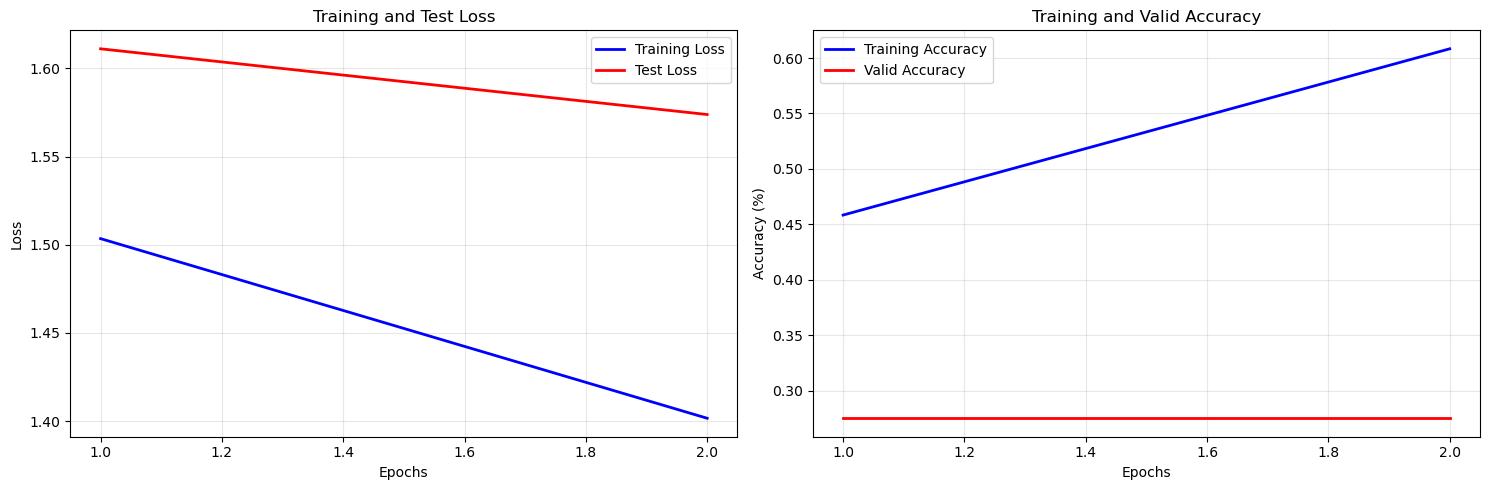

Epoch 3/15:
Train Loss: 1.3602, Train Acc: 0.5833
Valid Loss: 1.5106, Valid Acc: 0.4000
--------------------------------------------------


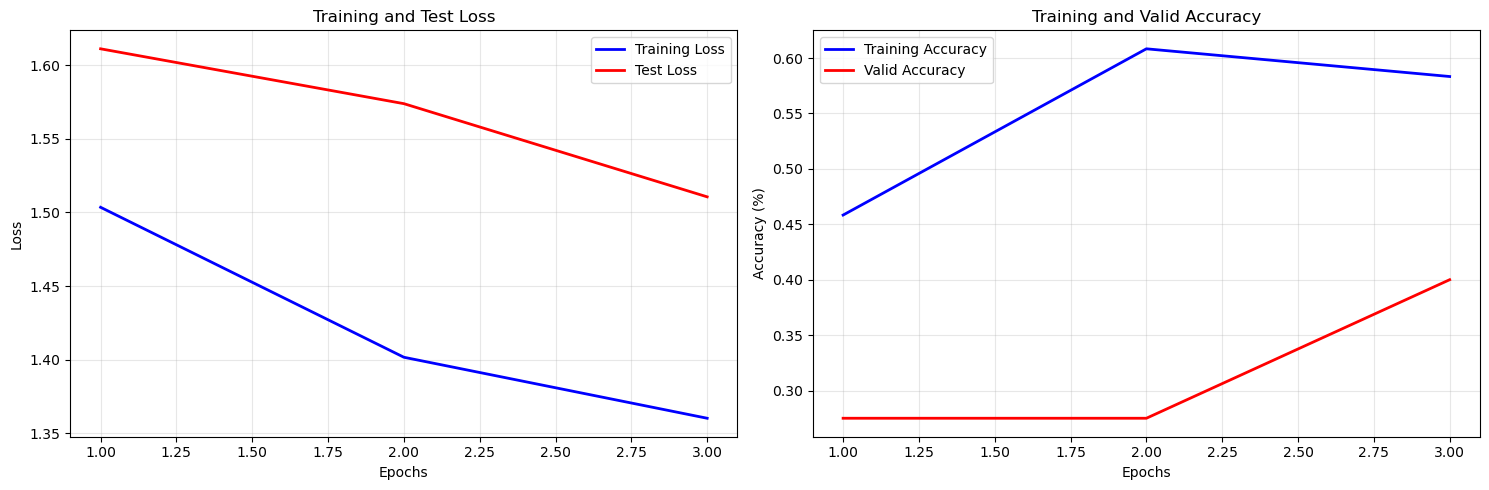

Epoch 4/15:
Train Loss: 1.3269, Train Acc: 0.6583
Valid Loss: 1.5414, Valid Acc: 0.3500
--------------------------------------------------


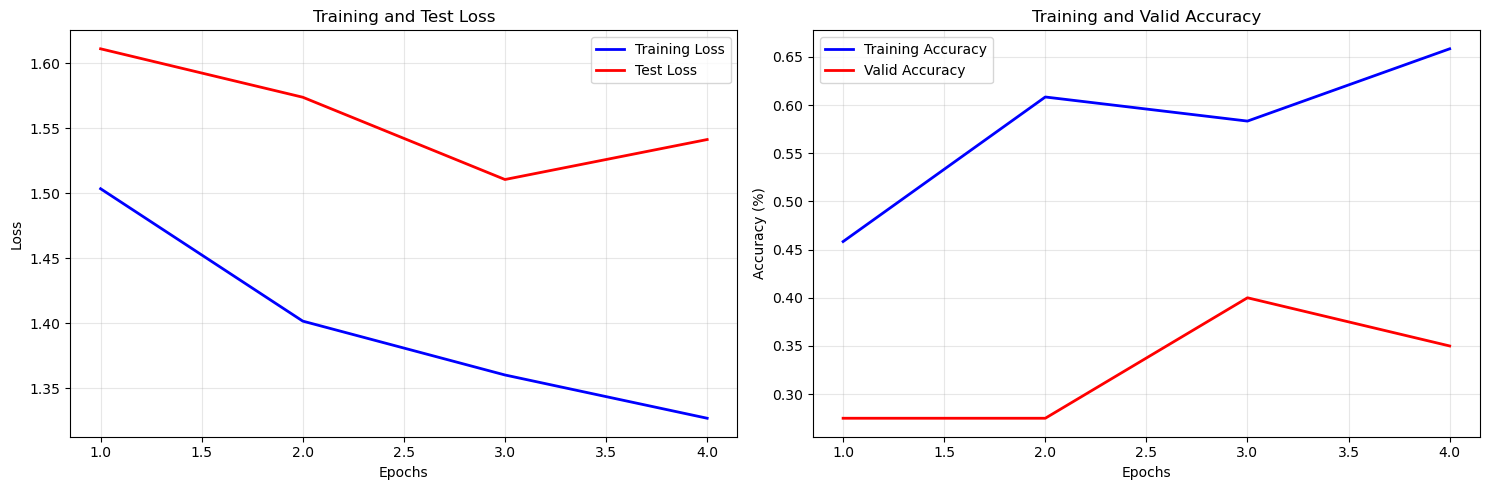

Epoch 5/15:
Train Loss: 1.2972, Train Acc: 0.7333
Valid Loss: 1.5022, Valid Acc: 0.4750
--------------------------------------------------


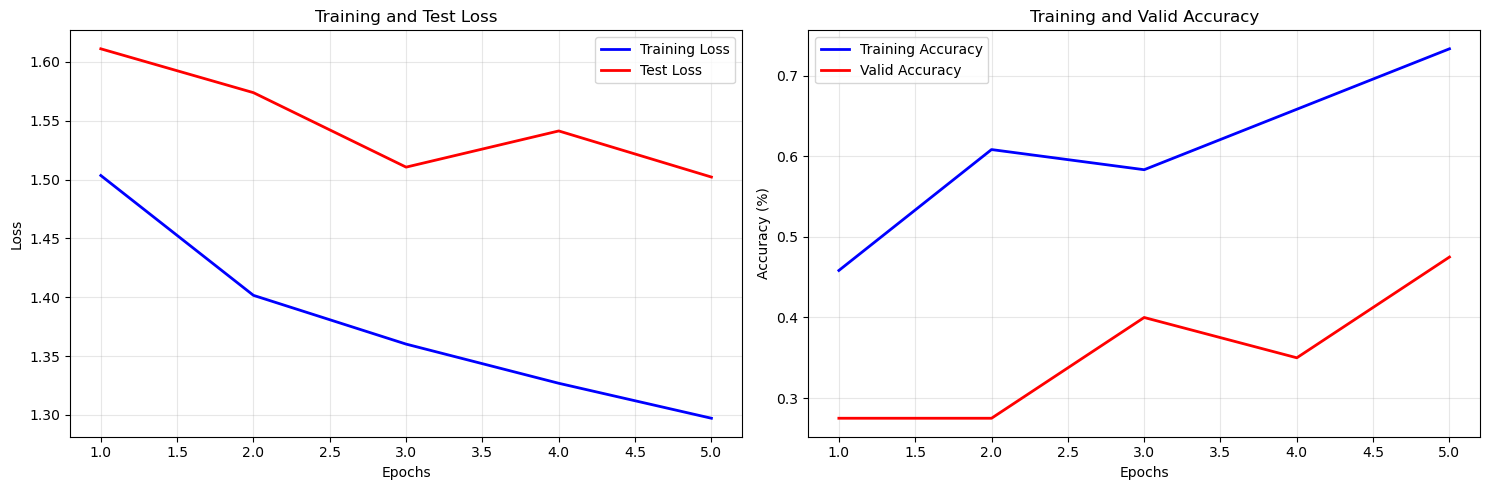

Epoch 6/15:
Train Loss: 1.2326, Train Acc: 0.7667
Valid Loss: 1.4933, Valid Acc: 0.4000
--------------------------------------------------


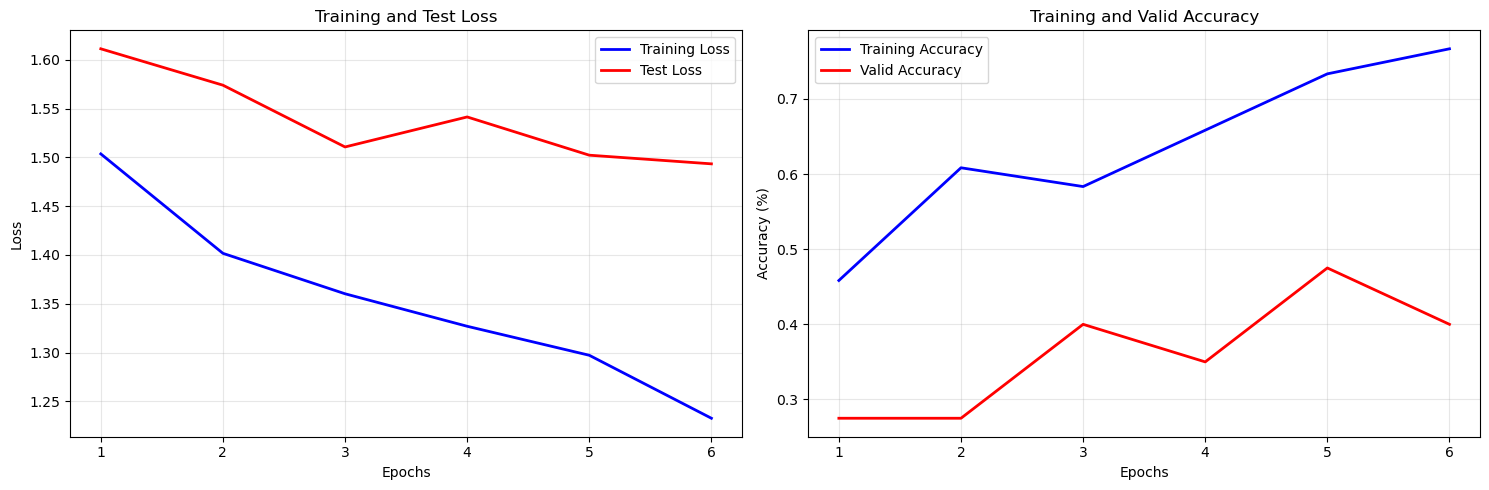

Epoch 7/15:
Train Loss: 1.2378, Train Acc: 0.7583
Valid Loss: 1.4783, Valid Acc: 0.4750
--------------------------------------------------


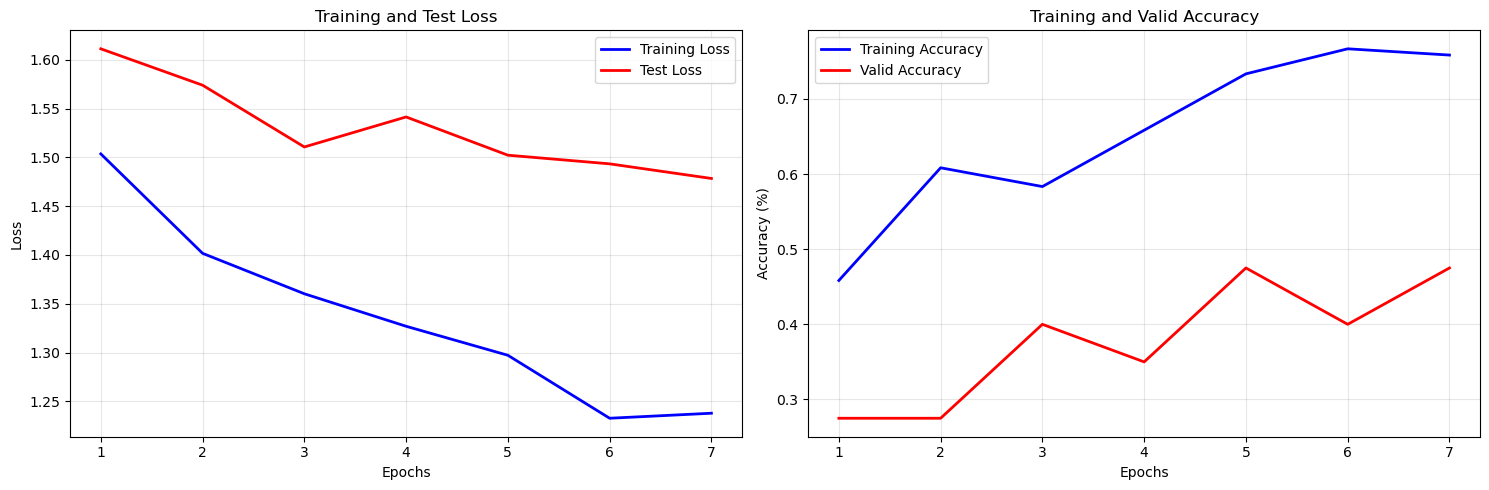

Epoch 8/15:
Train Loss: 1.1932, Train Acc: 0.8000
Valid Loss: 1.4612, Valid Acc: 0.4500
--------------------------------------------------


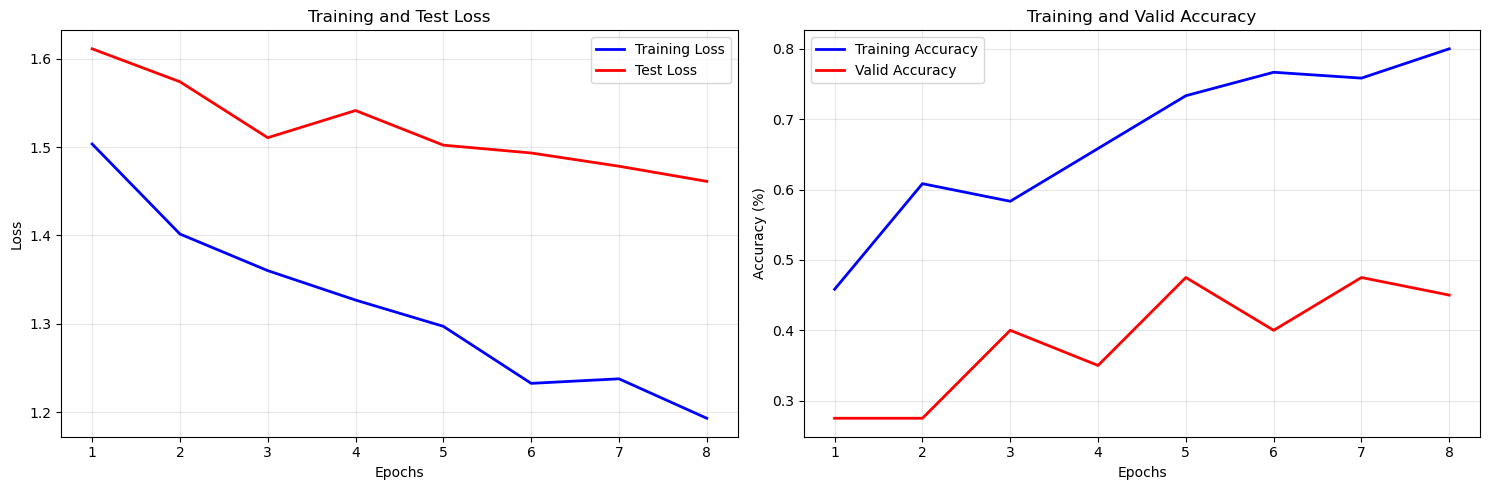

Epoch 9/15:
Train Loss: 1.1778, Train Acc: 0.8000
Valid Loss: 1.4364, Valid Acc: 0.5000
--------------------------------------------------


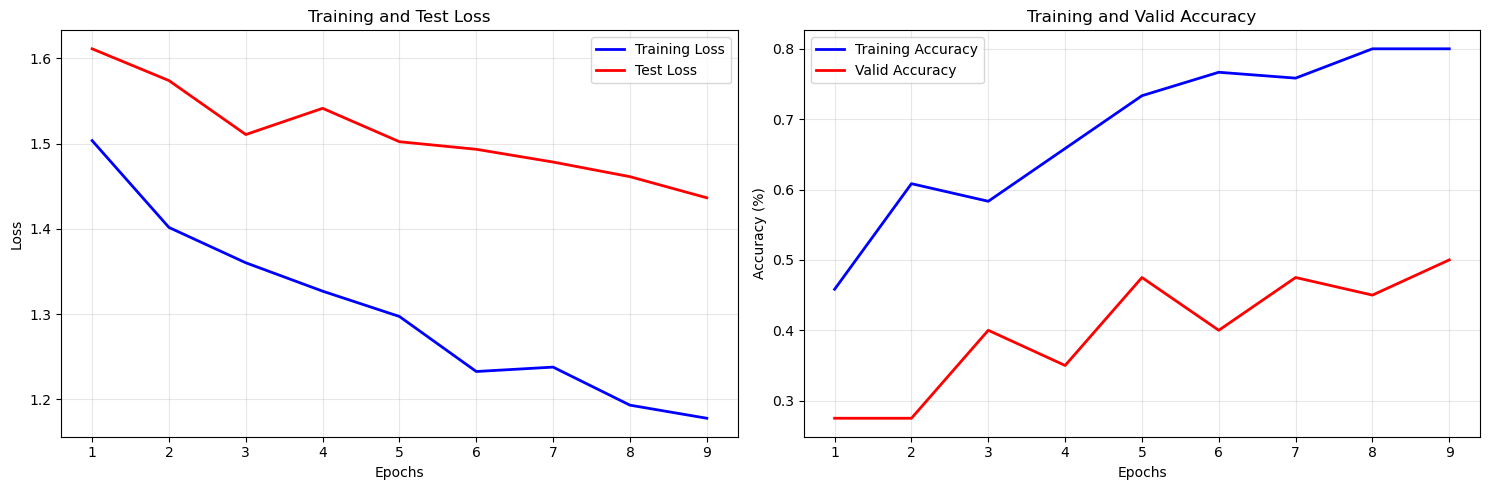

Epoch 10/15:
Train Loss: 1.1790, Train Acc: 0.7833
Valid Loss: 1.4376, Valid Acc: 0.4750
--------------------------------------------------


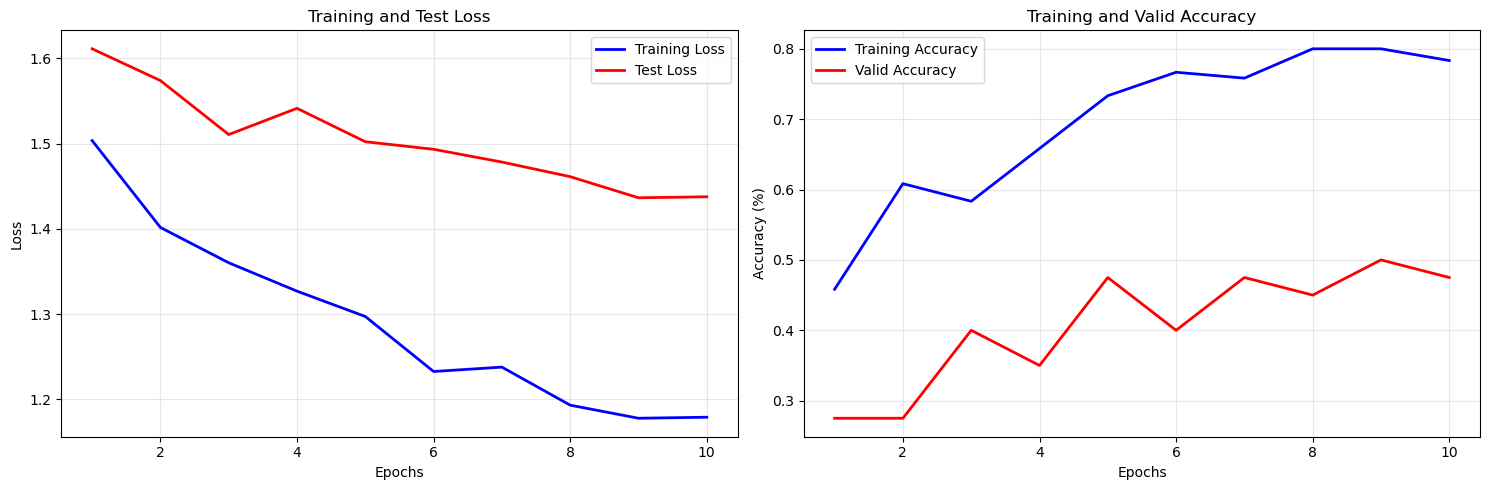

Epoch 11/15:
Train Loss: 1.1744, Train Acc: 0.8167
Valid Loss: 1.4373, Valid Acc: 0.5250
--------------------------------------------------


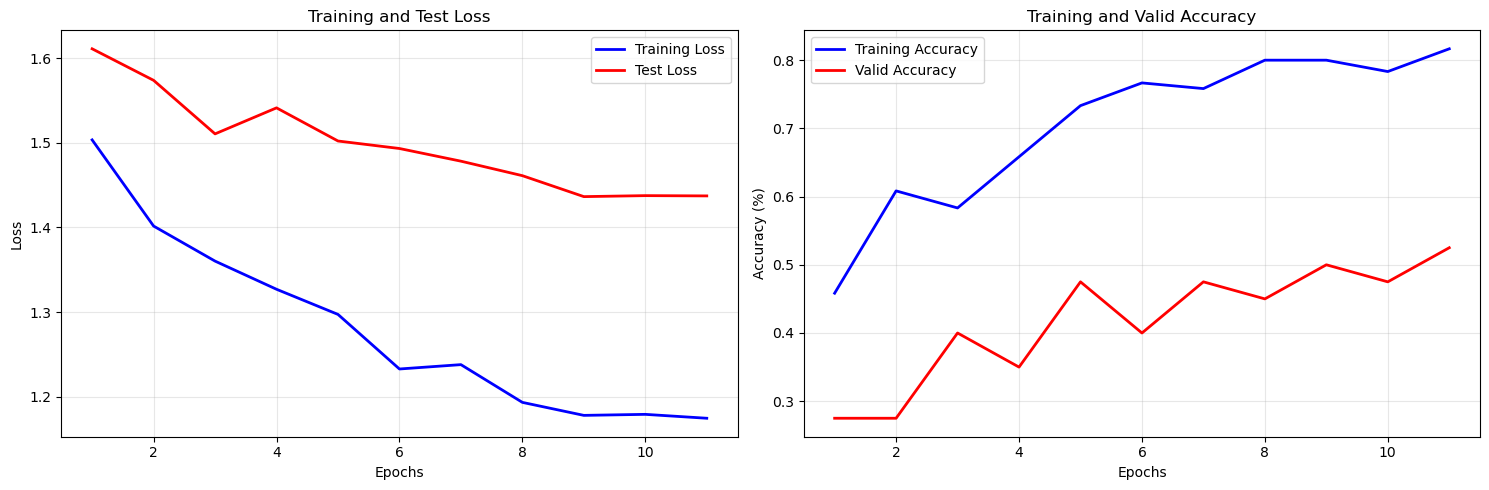

Epoch 12/15:
Train Loss: 1.1418, Train Acc: 0.8417
Valid Loss: 1.4564, Valid Acc: 0.5000
--------------------------------------------------


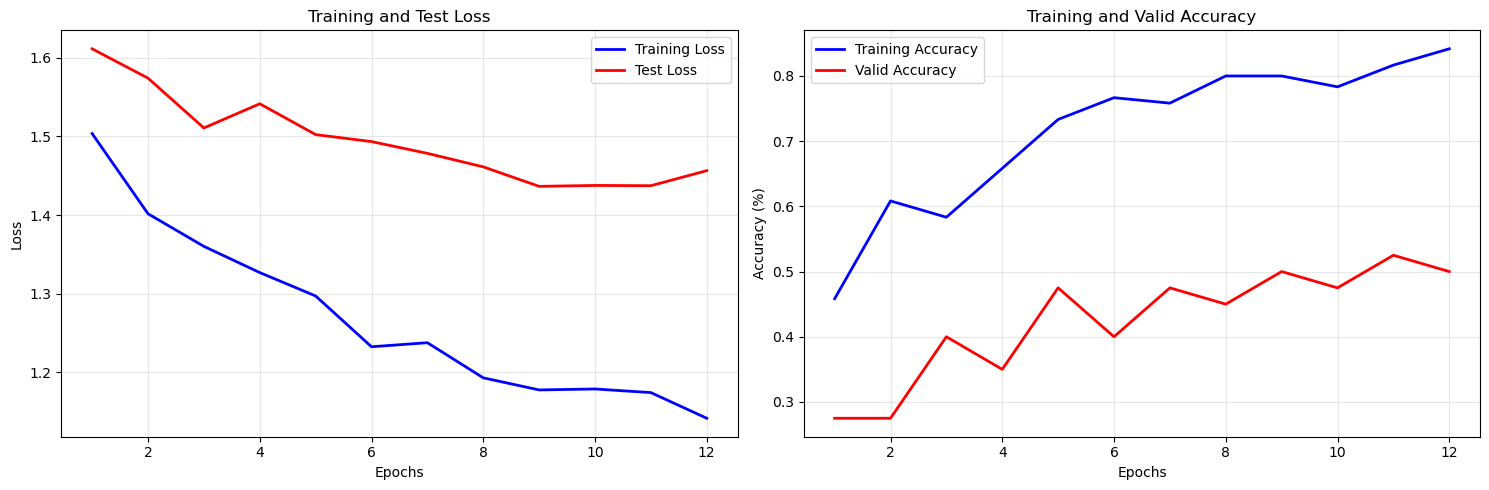

Epoch 13/15:
Train Loss: 1.1188, Train Acc: 0.8750
Valid Loss: 1.4097, Valid Acc: 0.5250
--------------------------------------------------


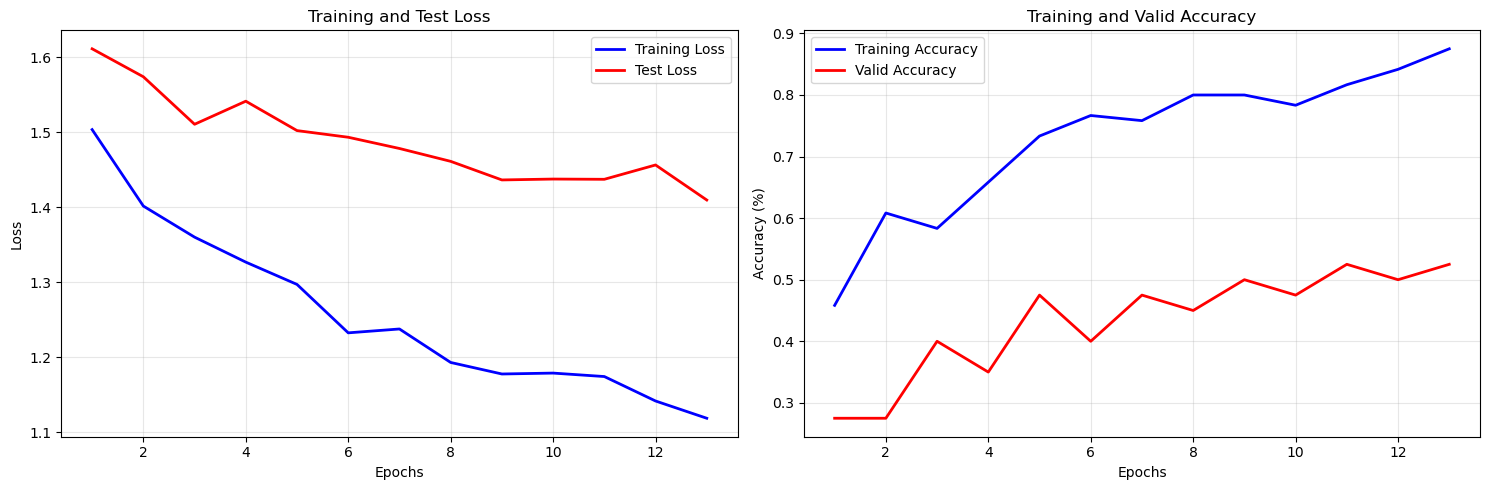

Epoch 14/15:
Train Loss: 1.1329, Train Acc: 0.8500
Valid Loss: 1.4074, Valid Acc: 0.5750
--------------------------------------------------


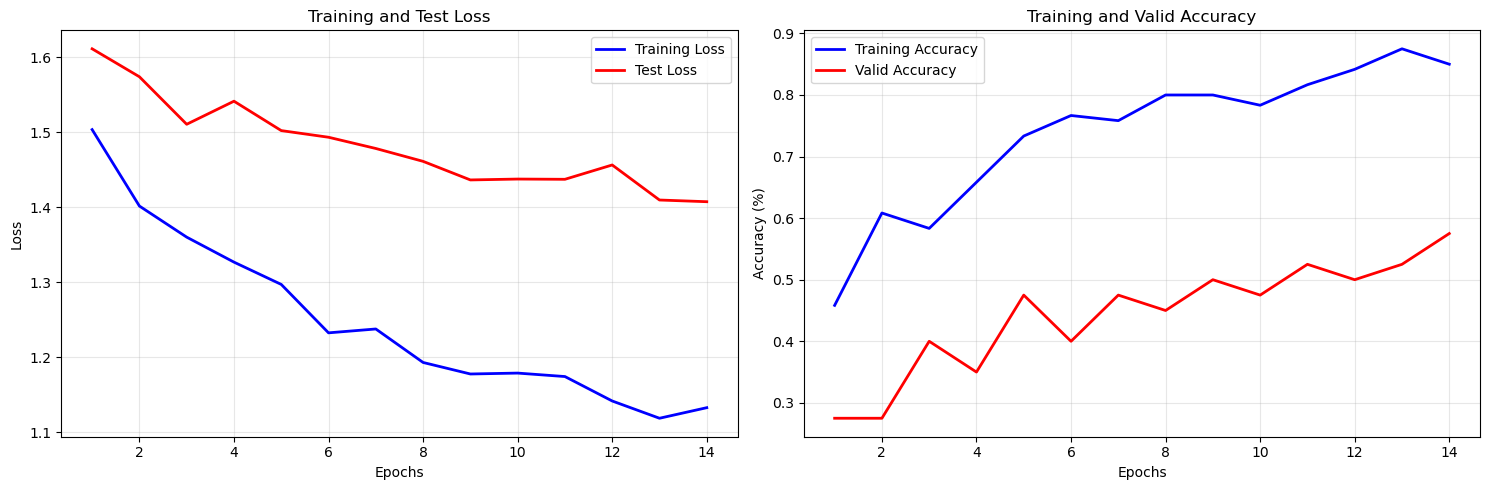

Epoch 15/15:
Train Loss: 1.1349, Train Acc: 0.8167
Valid Loss: 1.4478, Valid Acc: 0.5250
--------------------------------------------------


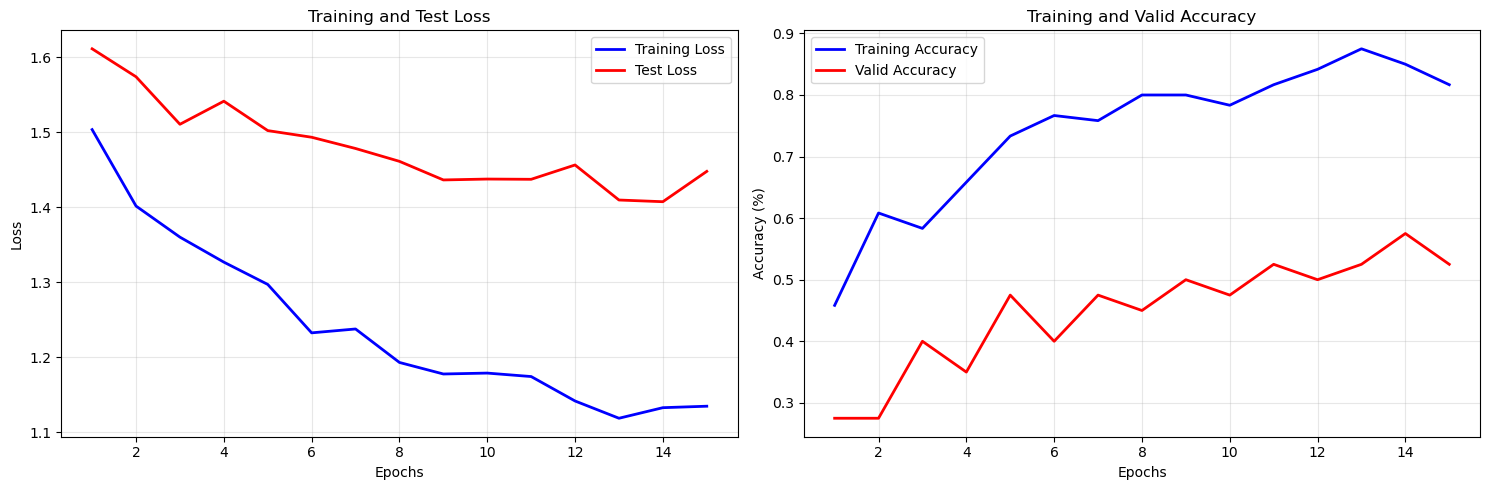

Обучение завершено!


In [222]:
from torch.utils.data import DataLoader
from IPython.display import clear_output
dir = "D:\Projects\DeepLearningSound\sound_classification_dataset"

train_data = SimpleAudioDataset(train_df, do_augmentation=True) 
valid_data = SimpleAudioDataset(valid_df) 

train_loader = DataLoader(train_data, batch_size=8, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=8, shuffle=False, num_workers=0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = SoundClassificationModel(input_dim=80000, input_size=16000, num_classes=5, p=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 15

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    train_batches = 0

    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad() 
        predictions = model(signals)
        loss = criterion(predictions, labels)
        accuracy = calculate_accuracy(predictions, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        train_accuracy += accuracy
        train_batches += 1


    model.eval()
    valid_loss = 0.0
    valid_accuracy = 0.0
    valid_batches = 0
    
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)
            
            valid_mask = labels != -1
            if valid_mask.sum() == 0:
                continue
                
            signals = signals[valid_mask]
            labels = labels[valid_mask]
            
            if labels.min() > 0:
                labels = labels - 1
            
            predictions = model(signals)
            loss = criterion(predictions, labels)
            accuracy = calculate_accuracy(predictions, labels)

            valid_loss += loss.item()
            valid_accuracy += accuracy
            valid_batches += 1

    if train_batches > 0 and valid_batches > 0:
        epoch_train_loss = train_loss / train_batches
        epoch_train_acc = train_accuracy / train_batches
        epoch_valid_loss = valid_loss / valid_batches
        epoch_valid_acc = valid_accuracy / valid_batches

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)
        valid_losses.append(epoch_valid_loss)
        valid_accuracies.append(epoch_valid_acc)

        print(f'Epoch {epoch+1}/{n_epochs}:')
        print(f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}')
        print(f'Valid Loss: {epoch_valid_loss:.4f}, Valid Acc: {epoch_valid_acc:.4f}')
        print('-' * 50)

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)

print("Обучение завершено!")

In [223]:
print("Train Accuracy = ", train_accuracies[-1])
print("Valid Accuracy = ", valid_accuracies[-1])

Train Accuracy =  0.8166666666666667
Valid Accuracy =  0.525


### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cuda
ESC-50 Audio Classification Demo!


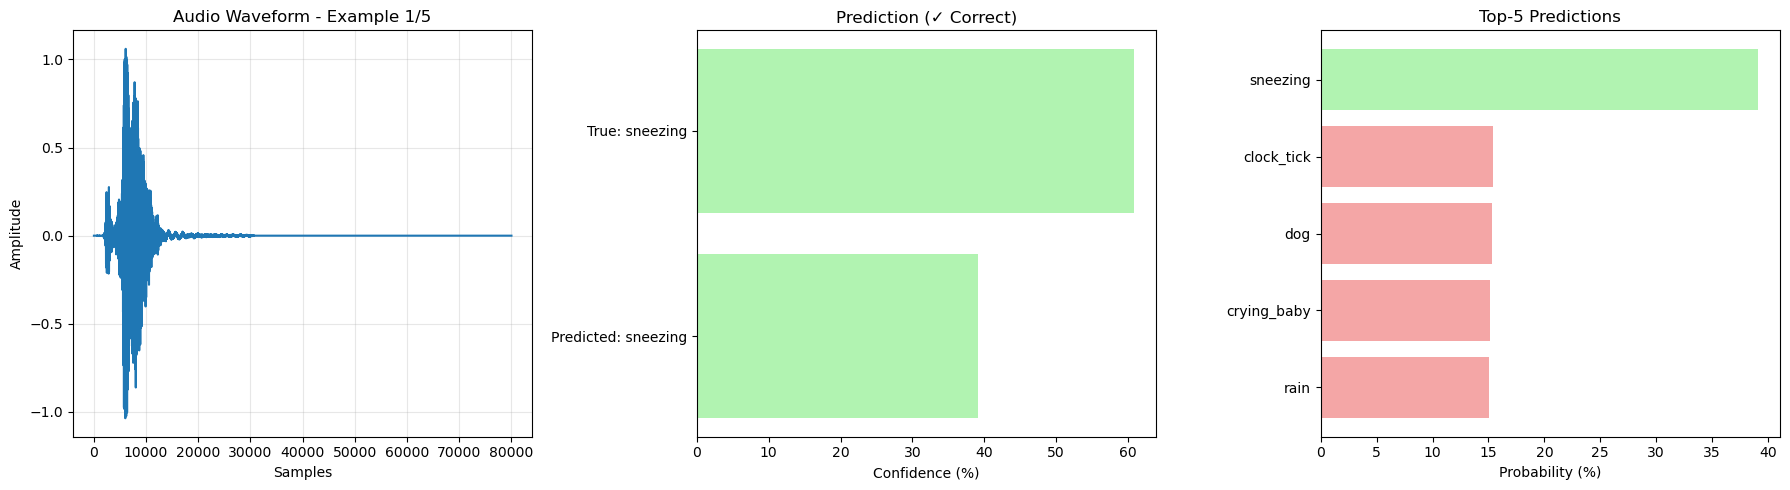

Playing: sneezing


Prediction: sneezing (39.11%)
True label: sneezing
Correct: True


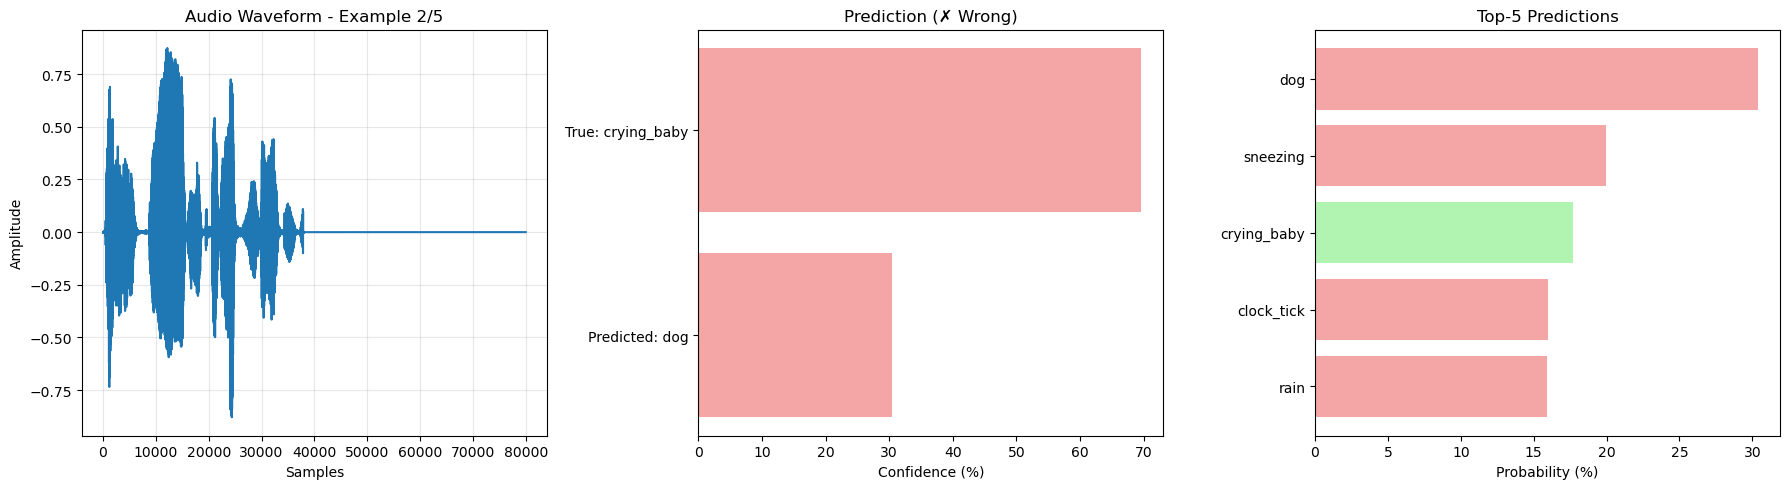

Playing: crying_baby


Prediction: dog (30.38%)
True label: crying_baby
Correct: False


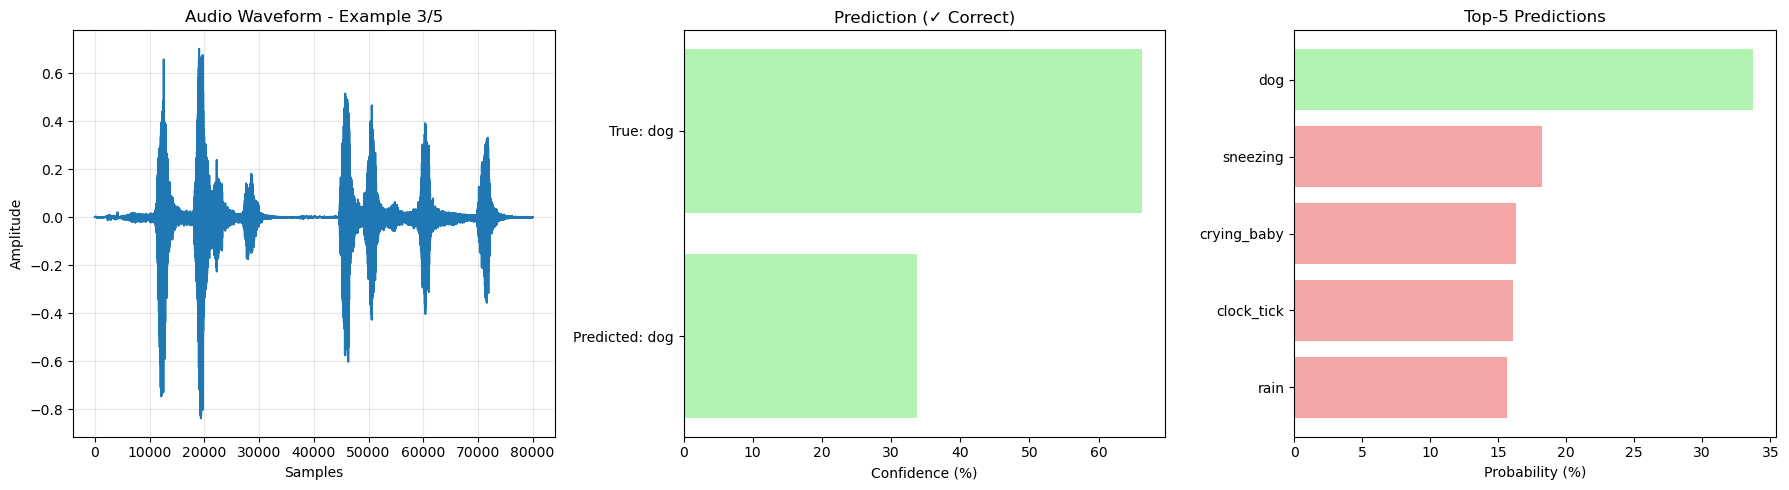

Playing: dog


Prediction: dog (33.70%)
True label: dog
Correct: True


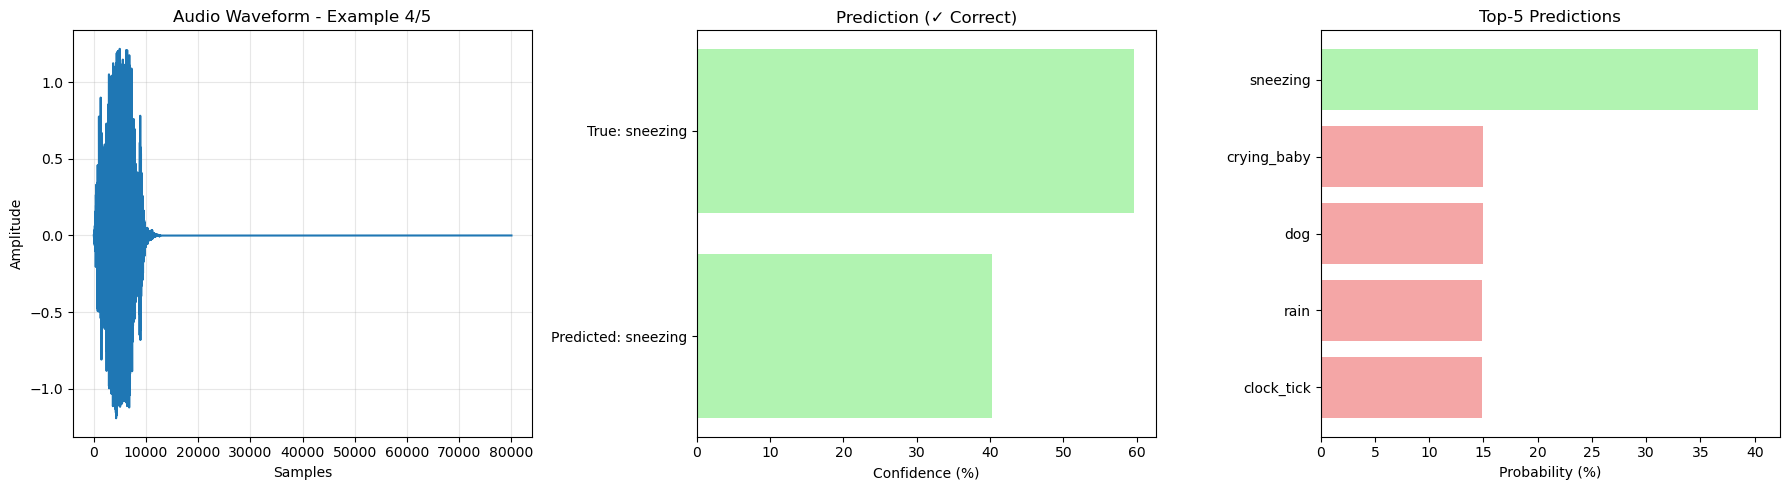

Playing: sneezing


Prediction: sneezing (40.31%)
True label: sneezing
Correct: True


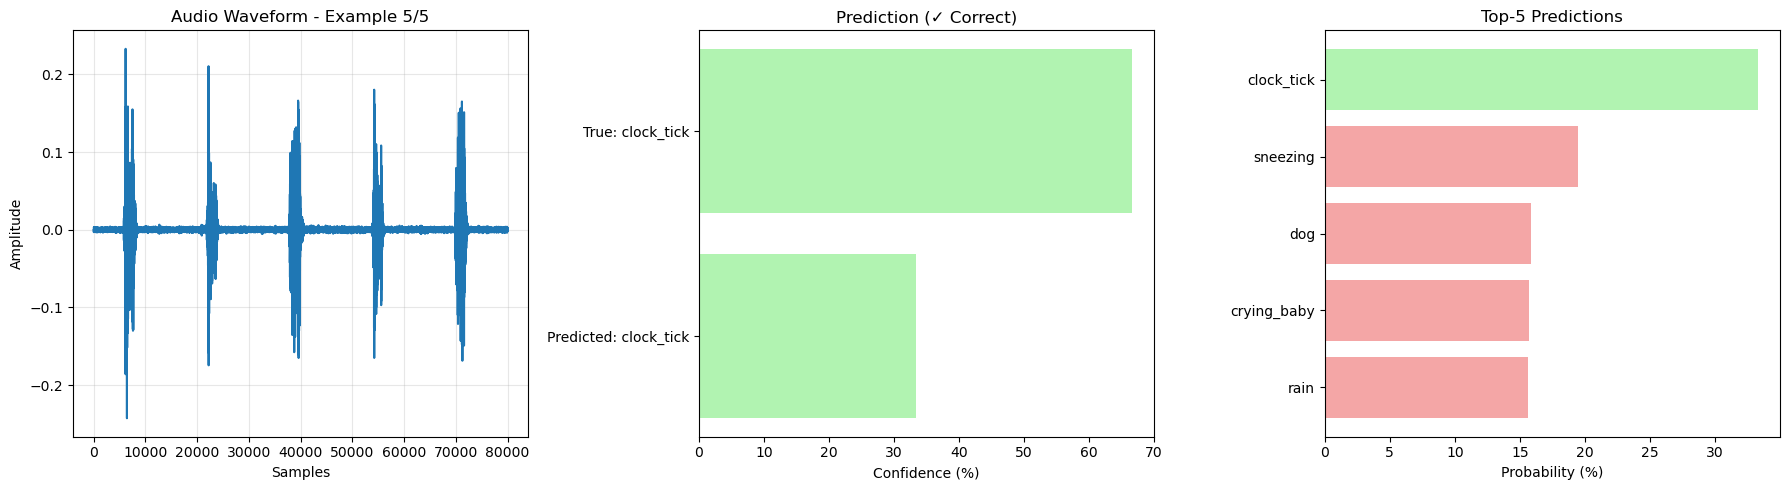

Playing: clock_tick


Prediction: clock_tick (33.32%)
True label: clock_tick
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 37/40
Accuracy: 92.50%


In [224]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [226]:
inverse_label_map = {i: v for v, i in label_map.items()}
inverse_label_map

{0: 'dog', 1: 'rain', 2: 'crying_baby', 3: 'clock_tick', 4: 'sneezing'}

In [227]:
test_data = SimpleAudioDataset(test_df, test = True)
test_loader = DataLoader(test_data, batch_size=len(test_df), shuffle=False)

preds = []
for signal in test_loader:
  signal = signal.to(device)
  prediction = model(signal)
  pred_label = torch.argmax(prediction, dim = 1)
  preds += pred_label.detach().cpu().tolist()
preds = np.array([inverse_label_map[p] for p in preds])

In [228]:
y_test_pred = np.array(preds)

In [231]:
submission = pd.read_csv("test.csv")
submission['category'] = y_test_pred
submission.to_csv("/submission.csv", index=False)

### **Report**

Сделала свёрточную нейросеть с 4мя свёрточными слоями